# MOF CO₂ Uptake — R²-Optimized Supervised Pipelines (with Baselines, Cleaning, and Correlations)

This notebook follows a **consistent, reproducible pipeline** for the MOF CO₂ uptake task and **optimizes models by R²** (coefficient of determination). We still **report RMSE & MAE** for interpretability.

**What this notebook does**  
1. Load data (`train.csv`) and define **FEATURES** and **TARGET**  
2. **Clean**: remove duplicate rows and redundant/constant columns  
3. Quick **EDA** and **correlation analysis** (Pearson & Spearman)  
4. Create **stratified splits** (by binning the target) to regularize validation  
5. Build **dummy baselines** (mean/median)  
6. Set up **ColumnTransformer** preprocessing shared by all models  
7. Train/tune multiple **regression models** (Ridge, Lasso, ElasticNet, Kernel Ridge, SVR, RandomForest, + XGBoost/LightGBM/CatBoost if available) with **RandomizedSearchCV** optimizing **R²**  
8. Show a **leaderboard** ranked by R², also printing RMSE & MAE  
9. (Optional) Refit best model on full data for downstream use


In [29]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd
from ydata_profiling import ProfileReport

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression, SGDRegressor
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error)

# save/load models
import joblib

# For the permutation importance implementation
from joblib import Parallel
from joblib import delayed
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Linear / kernel / tree models
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

# Optional (if installed)
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

RANDOM_SEED = 42
N_SPLITS = 5
N_JOBS = -1
N_ITER = 40  # tuning iterations per model
PRIMARY_SCORER = "r2"  # optimize by R²
VERBOSE = 1

print({"xgb": HAVE_XGB})


{'xgb': True}


## 1. Load Data & Define `FEATURES` and `TARGET`


In [30]:
# load data locally
DATA_DIR = "../data"
DATA_FILE = os.path.join(DATA_DIR, "train.csv")

try:
    df = pd.read_csv(DATA_FILE)
    print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

except FileNotFoundError:
    # Fallback: try to load from GitHub raw URL
    url = "https://github.com/AI4ChemS/CHE1147/raw/refs/heads/main/data/MOF_CoRE2019.csv"
    try:
        df = pd.read_csv(url)
        print(f"🌐 Loaded data from GitHub, shape = {df.shape}")
    except Exception as e:
        print(f"❌ Could not find {DATA_FILE} locally or on GitHub.")
        raise e

display(df.head())


✅ Loaded data from ../data\train.csv, shape = (5014, 328)


,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-I-3,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K
0,XAGCUE_clean,0.00,2.87682,6.41175,6.41175,487.410,0.000000,0.0000,0.101882,0.21558,...,2496.0,2784.0,7296.0,10752.0,10752.0,242.0856,523.7232,844.9008,1049.6448,1.266370
1,SOBZEQ_clean,2298.52,5.44324,7.06044,7.04565,0.000,0.738273,0.6363,0.000000,0.00000,...,496.0,632.0,1560.0,2240.0,2544.0,58.2840,130.2840,194.2144,231.0000,8.224130
2,AVAQIX01_clean,0.00,3.61603,5.36267,5.34980,600.353,0.000000,0.0000,0.226377,0.30062,...,672.0,1024.0,2400.0,3040.0,2688.0,91.7328,204.2656,276.2848,265.7760,3.694178
3,INURIS_clean,0.00,3.09799,5.07769,4.57779,253.440,0.000000,0.0000,0.077296,0.09856,...,2640.0,3840.0,9264.0,12720.0,13728.0,301.4544,713.6976,1037.0160,1127.9280,1.007227
4,KEDNOY_clean,0.00,3.63243,4.98967,4.98020,519.714,0.000000,0.0000,0.238159,0.28890,...,528.0,864.0,1920.0,2064.0,1920.0,72.0852,153.0144,199.7088,218.5200,3.617103


In [31]:
from MOF_descriptors import geometric_descriptors, linker_descriptors, metalcenter_descriptors, functionalgroup_descriptors, summed_linker_descriptors, summed_metalcenter_descriptors, summed_functionalgroup_descriptors

TARGET = "CO2 uptake at 0.15 bar and 298K"
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)

print("TARGET:", TARGET)
print("FEATURES (count):", len(FEATURES))

TARGET: CO2 uptake at 0.15 bar and 298K
FEATURES (count): 164


## 2. Cleaning — remove duplicates & redundant columns


In [32]:
# --- Remove duplicates ---
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

# --- Remove rows with NaN values ---
before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print(f"Removed {before - after} rows with NaN values. New shape: {df.shape}")

# --- Drop constant columns ---
constant_cols = [c for c in FEATURES if df[c].nunique(dropna=False) <= 1]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    df = df.drop(columns=constant_cols)
    FEATURES = [c for c in FEATURES if c not in constant_cols]

# --- Drop perfectly duplicated columns ---
to_drop = []
cols_list = list(FEATURES)
for i in range(len(cols_list)):
    c1 = cols_list[i]
    if c1 in to_drop: 
        continue
    for j in range(i+1, len(cols_list)):
        c2 = cols_list[j]
        if c2 in to_drop:
            continue
        if df[c1].equals(df[c2]):
            to_drop.append(c2)

if to_drop:
    print("Dropping duplicated columns:", to_drop)
    df = df.drop(columns=to_drop)
    FEATURES = [c for c in FEATURES if c not in to_drop]

print("Final FEATURES count after cleaning:", len(FEATURES))

Removed 14 duplicate rows. New shape: (5000, 328)
Removed 1 rows with NaN values. New shape: (4999, 328)
Dropping constant columns: ['sum-D_func-chi-0-all', 'sum-D_func-Z-0-all', 'sum-D_func-I-0-all', 'sum-D_func-I-1-all', 'sum-D_func-I-2-all', 'sum-D_func-I-3-all', 'sum-D_func-T-0-all', 'sum-D_func-S-0-all', 'sum-D_func-alpha-0-all', 'sum-D_lc-chi-0-all', 'sum-D_lc-Z-0-all', 'sum-D_lc-I-0-all', 'sum-D_lc-I-1-all', 'sum-D_lc-I-2-all', 'sum-D_lc-I-3-all', 'sum-D_lc-T-0-all', 'sum-D_lc-S-0-all', 'sum-D_lc-alpha-0-all', 'sum-D_mc_CRY-chi-0-all', 'sum-D_mc_CRY-Z-0-all', 'sum-D_mc_CRY-I-0-all', 'sum-D_mc_CRY-I-1-all', 'sum-D_mc_CRY-I-2-all', 'sum-D_mc_CRY-I-3-all', 'sum-D_mc_CRY-T-0-all', 'sum-D_mc_CRY-S-0-all']
Final FEATURES count after cleaning: 138


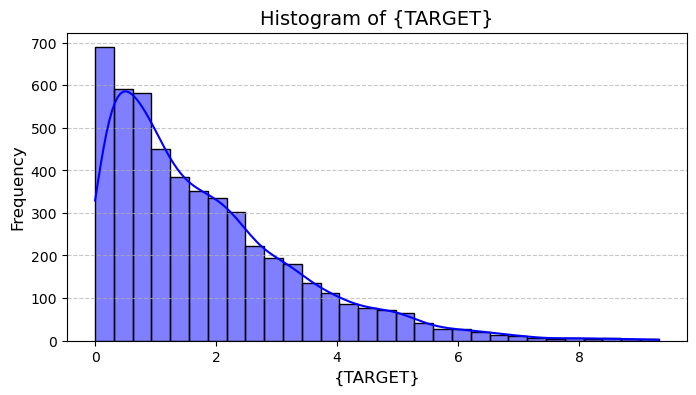

In [33]:
# Plot histogram of the target
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET], kde=True, bins=30, color='blue')

# Add labels and title
plt.xlabel("{TARGET}", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of {TARGET}", fontsize=14)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Based on this histogram and the tail of the distribution, we will use top 10% of the dataset as the threshold for the uptake, thus binarizing our continuous target variable. We use this threshold to define a new column with binary values of 0 and 1 for bad and good materials. 

In [34]:
TARGET_BINARY = "target_binned" # name of the new binary target column
THRESHOLD = df[TARGET].quantile(0.9)  # Top 10% of the dataset
df[TARGET_BINARY] = (df[TARGET] > THRESHOLD).astype(int)

In [35]:
XX = 0.7
YY = 0.3
df_train_stratified, df_test_stratified = train_test_split(
    df,
    train_size=XX,
    test_size=YY,
    random_state=RANDOM_SEED,
    stratify=df[TARGET_BINARY]
)
df_train_stratified.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,target_binned
1985,TONTOH_clean,1603.22,3.80615,8.07783,8.07783,0.00000,0.597469,0.48330,0.000000,0.00000,...,576.0,1392.0,1896.0,2028.0,59.4744,126.7728,168.9072,206.4732,0.966465,0
3577,jacs.5b12237_ja5b12237_si_004_clean,1938.94,6.54448,11.25439,11.14603,1.64378,0.754409,0.54716,0.000000,0.00000,...,8784.0,21600.0,29856.0,30720.0,683.1072,1658.4864,2385.7584,2565.7056,0.429190,0
663,UMOYOM06_clean,2756.21,5.35990,9.27242,9.27242,0.00000,1.292570,0.70402,0.000000,0.00000,...,1470.0,3654.0,5268.0,6276.0,110.9496,269.4846,407.4000,500.1228,0.440871,0
1344,EXENAX_clean,0.00,3.71955,4.98437,4.67631,770.44400,0.000000,0.00000,0.186336,0.35298,...,464.0,1056.0,1248.0,1040.0,70.1464,108.3024,153.5088,155.5536,0.525364,0
3014,KIDVIE_clean,1188.51,4.27938,6.06928,6.06928,0.00000,0.253349,0.40384,0.000000,0.00000,...,176.0,336.0,224.0,64.0,26.5392,45.4608,53.0272,34.1056,1.414321,0


In [36]:
df_test_stratified.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,target_binned
3274,ROYREE_clean,1002.50,5.04516,6.65259,6.56274,0.000,0.276015,0.32402,0.000000,0.00000,...,2880.0,7344.0,11088.0,13488.0,225.0084,545.9280,841.0608,1049.7888,3.585590,0
3110,jacs.5b12516_ja5b12516_si_003_clean,1692.25,6.74383,8.53606,8.51304,0.000,0.338465,0.47316,0.000000,0.00000,...,2760.0,7200.0,10824.0,10596.0,170.4072,446.6616,713.9184,764.8068,0.166750,0
1598,WECFAN01_clean,0.00,3.69787,4.19243,4.18729,196.906,0.000000,0.00000,0.118092,0.15628,...,724.0,1760.0,2344.0,2484.0,55.7192,130.1300,187.9680,206.9500,2.630909,0
3460,WOPSOL01_clean,1457.92,10.70959,10.90023,10.90023,0.000,0.482610,0.57026,0.000000,0.00000,...,240.0,576.0,768.0,750.0,24.6432,52.1136,75.7872,85.6158,4.890356,1
796,ZAVQAQ_clean,1277.16,4.48097,5.33865,5.32560,0.000,0.294404,0.39008,0.000000,0.00000,...,648.0,1584.0,2216.0,2432.0,60.2940,134.1776,197.7256,230.2704,4.681026,1


## 3. Quick EDA & Target Distribution


Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 5013
Columns: 303 entries, MOFname to target_binned
dtypes: float64(301), int32(1), object(1)
memory usage: 11.6+ MB

Describe (numeric):


,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,density [g/cm^3],...,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,target_binned
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,...,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,890.891881,4.952574,7.031972,6.942192,141.751504,0.338061,0.292100,0.051973,0.070852,1.293036,...,1097.708342,2765.279456,3796.642128,3961.019404,170.899516,219.169256,520.712459,346.103644,1.798984,0.100020
std,808.654377,2.773695,3.665367,3.600733,264.090934,0.513430,0.256676,0.092246,0.112880,0.467455,...,1136.526740,3133.510724,4459.690366,4815.290040,4509.828206,446.527294,13379.883686,767.336422,1.545871,0.300057
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.063653,...,8.000000,8.000000,0.000000,0.000000,3.081200,4.620000,0.000000,0.000000,0.000027,0.000000
25%,0.000000,3.390940,4.890055,4.834075,0.000000,0.000000,0.000000,0.000000,0.000000,0.998865,...,392.000000,912.000000,1176.000000,1080.000000,39.808800,86.068800,111.537000,113.441900,0.603504,0.000000
50%,888.739000,4.201470,5.898620,5.857930,0.000000,0.223676,0.307240,0.000000,0.000000,1.233370,...,744.000000,1800.000000,2384.000000,2448.000000,64.957000,147.840000,209.387200,229.540800,1.388390,0.000000
75%,1547.015000,5.755400,8.012355,7.899765,184.365000,0.478781,0.501290,0.080555,0.129930,1.534315,...,1410.000000,3534.000000,4974.000000,5308.000000,112.902400,263.141000,388.973600,441.182600,2.579082,0.000000
max,3270.130000,71.501970,71.641190,71.641190,1594.450000,15.098600,0.961060,0.965610,0.581820,4.470600,...,10692.000000,62268.000000,72360.000000,49776.000000,312383.998800,27158.568000,937250.563200,45138.225600,9.318191,1.000000


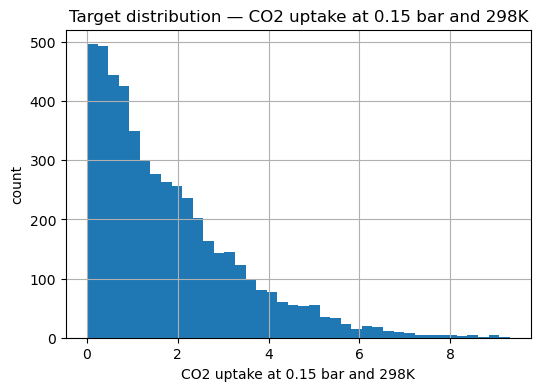

In [37]:
print("Info:")
df.info()

print("\nDescribe (numeric):")
display(df.describe())

plt.figure(figsize=(6,4))
df[TARGET].hist(bins=40)
plt.title(f"Target distribution — {TARGET}")
plt.xlabel(TARGET); plt.ylabel("count")
plt.show()


In [38]:
redundant_features = [
    col for col in FEATURES 
    if df[col].nunique() <= 1
]

# update feature set
print(f"Number of features before: {len(FEATURES)}")
FEATURES = [feature for feature in FEATURES if not feature in redundant_features]
print(f"Number of features after: {len(FEATURES)}")

Number of features before: 138
Number of features after: 138


## 4. Correlation Analysis (Pearson & Spearman)


Top 10 Pearson correlations with target:
CO2 uptake at 0.15 bar and 298K    1.000000
sum-D_lc-T-1-all                   0.103190
sum-D_mc_CRY-chi-2-all             0.082283
sum-D_mc_CRY-chi-3-all             0.062958
sum-D_func-alpha-1-all             0.062486
sum-D_mc_CRY-chi-1-all             0.054162
sum-D_lc-alpha-1-all               0.044645
sum-D_func-T-1-all                 0.042999
sum-D_func-alpha-3-all             0.033540
sum-func-alpha-0-all               0.032526
Name: CO2 uptake at 0.15 bar and 298K, dtype: float64

Top 10 Spearman correlations with target:
CO2 uptake at 0.15 bar and 298K    1.000000
sum-D_lc-T-1-all                   0.123106
sum-D_lc-alpha-1-all               0.099897
density [g/cm^3]                   0.091090
sum-D_mc_CRY-chi-2-all             0.066394
sum-D_lc-S-1-all                   0.065040
sum-D_func-Z-2-all                 0.051691
sum-D_func-Z-1-all                 0.049374
sum-D_func-Z-3-all                 0.040863
sum-D_func-S-1-all        

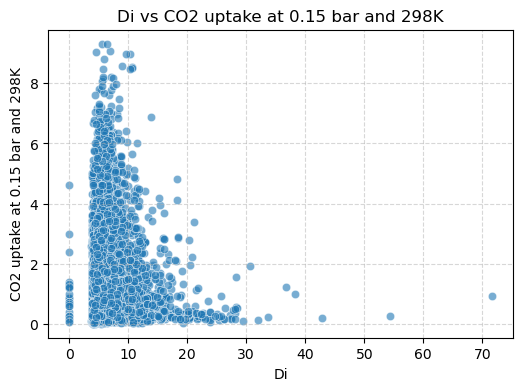

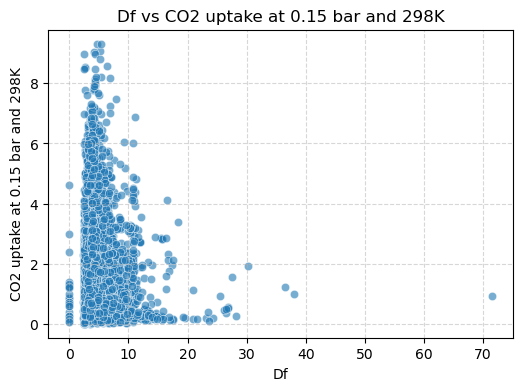

In [39]:
# add code here
# Calculate the correlation of all features with the target

# Pearson correlation (linear relationships)
pearson_corr = df[FEATURES + [TARGET]].corr(method="pearson")[TARGET].sort_values(ascending=False)

# Spearman correlation (monotonic relationships, rank-based)
spearman_corr = df[FEATURES + [TARGET]].corr(method="spearman")[TARGET].sort_values(ascending=False)

print("Top 10 Pearson correlations with target:")
print(pearson_corr.head(10))
print("\nTop 10 Spearman correlations with target:")
print(spearman_corr.head(10))

# --- Example scatter plots ---
example_features = ["Density", FEATURES[0], FEATURES[1]]  # replace if needed
for feat in example_features:
    if feat in df.columns:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[feat], y=df[TARGET], alpha=0.6)
        plt.xlabel(feat)
        plt.ylabel(TARGET)
        plt.title(f"{feat} vs {TARGET}")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

## 6. Preprocessing with ColumnTransformer (shared across all models)


In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

numeric_cols = [c for c in df_train_stratified.columns if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in df_train_stratified.columns if not pd.api.types.is_numeric_dtype(df[c])]

numeric_proc = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

categorical_proc = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_proc, numeric_cols),
        ("cat", categorical_proc, categorical_cols),
    ],
    remainder="drop",
    n_jobs=-1
)
print("Numeric/Categorical:", len(numeric_cols), len(categorical_cols))


Numeric/Categorical: 302 1


## 7. Baseline (Dummy) Models


In [44]:
# Build DummyRegressors
dummyregressor_mean = DummyRegressor(strategy='mean')
dummyregressor_median = DummyRegressor(strategy='median')

# Fit Dummy Regressors
dummyregressor_mean.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])
dummyregressor_median.fit(df_train_stratified[FEATURES], df_train_stratified[TARGET])

,strategy,'median'
,constant,None
,quantile,None


In [46]:
def get_regression_metrics(model, X, y_true):
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = model.predict(X)

    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    maximum_error = max_error(y_true, y_predicted)
    mape =  np.mean(np.abs((y_true - y_predicted) / np.maximum(1e-8, np.abs(y_true))))

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

dummy_regressors = [
    ('mean', dummyregressor_mean),
    ('median', dummyregressor_median)
]

In [47]:
dummy_regressor_results_test = {} # initialize empty dictionary
dummy_regressor_results_train = {}

# loop over the dummy_regressor list
# if you have a tuple regressorname, regressor = (a, b) that is automatically expanded into the variables
# a = regressorname, b = regressor
for regressorname, regressor in dummy_regressors:
    print(f"Calculating metrics for {regressorname}")
    dummy_regressor_results_test[regressorname] = get_regression_metrics(regressor, df_test_stratified[FEATURES], df_test_stratified[TARGET])
    dummy_regressor_results_train[regressorname] = get_regression_metrics(regressor, df_train_stratified[FEATURES], df_train_stratified[TARGET])

Calculating metrics for mean
Calculating metrics for median


In [48]:
print("Dummy Regressor Results - Train & Test Set")

for regressorname, metrics in dummy_regressor_results_train.items():
    print(f"{regressorname} (Train): {metrics}")
    
for regressorname, metrics in dummy_regressor_results_test.items():
    print(f"{regressorname} (Test): {metrics}")

Dummy Regressor Results - Train & Test Set
mean (Train): {'mae': 1.2118106999469893, 'mse': 2.3927216840027428, 'max_error': 7.521148355592141, 'mape': 22.422078886200428}
median (Train): {'mae': 1.1695815735491284, 'mse': 2.5650645413404596, 'max_error': 7.9362903281, 'mape': 17.22071504258634}
mean (Test): {'mae': 1.2059301493720043, 'mse': 2.3811234683970577, 'max_error': 7.285988407992139, 'mape': 3.4768958593568406}
median (Test): {'mae': 1.1731846154796668, 'mse': 2.5588381737071826, 'max_error': 7.701130380499999, 'mape': 2.6572663493996327}


## 8. Model Factories with Hyperparameter Spaces (focus on regularization)


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

import numpy as np

def make_ridge():
    pipe = Pipeline([("prep", preprocess), ("model", Ridge(random_state=42))])
    params = {"model__alpha": np.logspace(-4, 4, 60)}
    return "Ridge", pipe, params

def make_lasso():
    pipe = Pipeline([("prep", preprocess), ("model", Lasso(random_state=42, max_iter=10000))])
    params = {"model__alpha": np.logspace(-5, 2, 60)}
    return "Lasso", pipe, params

def make_enet():
    pipe = Pipeline([("prep", preprocess), ("model", ElasticNet(random_state=42, max_iter=10000))])
    params = {"model__alpha": np.logspace(-5, 2, 60), "model__l1_ratio": np.linspace(0.0, 1.0, 21)}
    return "ElasticNet", pipe, params

def make_krr():
    pipe = Pipeline([("prep", preprocess), ("model", KernelRidge())])
    params = {
        "model__alpha": np.logspace(-4, 3, 40),
        "model__kernel": ["rbf","laplacian","poly","sigmoid"],
        "model__gamma": np.logspace(-5, 1, 30),
        "model__degree": [2,3,4],
        "model__coef0": np.linspace(0.0, 2.0, 11),
    }
    return "KernelRidge", pipe, params

def make_svr():
    pipe = Pipeline([("prep", preprocess), ("model", SVR())])
    params = {
        "model__kernel": ["rbf","poly","sigmoid"],
        "model__C": np.logspace(-2, 3, 30),
        "model__gamma": np.logspace(-5, 1, 20),
        "model__epsilon": np.logspace(-4, -1, 8),
        "model__degree": [2,3,4],
        "model__coef0": np.linspace(0, 2, 9),
    }
    return "SVR", pipe, params

def make_rf():
    pipe = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42))])
    params = {
        "model__n_estimators": [400, 800, 1200],
        "model__max_depth": [None, 8, 12, 16, 24],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": ["sqrt", "log2", None],
        "model__bootstrap": [True, False],
    }
    return "RandomForest", pipe, params

def make_extratrees():
    pipe = Pipeline([("prep", preprocess), ("model", ExtraTreesRegressor(random_state=42))])
    params = {
        "model__n_estimators": [600, 1000, 1400],
        "model__max_depth": [None, 8, 12, 16],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
    return "ExtraTrees", pipe, params

# Optional
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

def make_xgb():
    if not HAVE_XGB: return None
    pipe = Pipeline([("prep", preprocess), ("model", XGBRegressor(random_state=42, tree_method="hist"))])
    params = {
        "model__n_estimators": [800, 1200, 1600],
        "model__learning_rate": [0.02, 0.03, 0.05],
        "model__max_depth": [4,6,8,10],
        "model__min_child_weight": [1,3,5],
        "model__subsample": [0.7,0.8,1.0],
        "model__colsample_bytree": [0.7,0.8,1.0],
        "model__reg_alpha": [0, 0.1, 0.5, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0],
    }
    return "XGBoost", pipe, params

factories = [make_ridge, make_lasso, make_enet, make_krr, make_svr, make_rf, make_extratrees, make_xgb]
models = [f() for f in factories]
models = [m for m in models if m is not None]
print("Models:", [m[0] for m in models])


## 9. Tuning Helper (optimize by R²) and Evaluation (also show RMSE & MAE)


In [ ]:
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def tune_and_eval(label, pipe, param_dist, X, y, cv, n_iter=40):
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="r2",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1,
        refit=True
    )
    search.fit(X, y)
    best_pipe = search.best_estimator_
    y_pred_cv = cross_val_predict(best_pipe, X, y, cv=cv, n_jobs=-1, verbose=0)
    r2_cv  = r2_score(y, y_pred_cv)
    rmse_cv = mean_squared_error(y, y_pred_cv, squared=False)
    mae_cv = mean_absolute_error(y, y_pred_cv)

    best_pipe.fit(X_train, y_train)
    y_val_pred = best_pipe.predict(X_valid)
    r2_val  = r2_score(y_valid, y_val_pred)
    rmse_val = mean_squared_error(y_valid, y_val_pred, squared=False)
    mae_val = mean_absolute_error(y_valid, y_val_pred)

    print(f"\\n[{label}] Best CV R2={search.best_score_:.5f}")
    print("  Best params:", search.best_params_)
    print(f"  CV (R2/RMSE/MAE): {r2_cv:.5f} / {rmse_cv:.5f} / {mae_cv:.5f}")
    print(f"  Hold-out (R2/RMSE/MAE): {r2_val:.5f} / {rmse_val:.5f} / {mae_val:.5f}")

    return {
        "model": label,
        "best_cv_r2": search.best_score_,
        "cv_rmse": rmse_cv,
        "cv_mae": mae_cv,
        "holdout_r2": r2_val,
        "holdout_rmse": rmse_val,
        "holdout_mae": mae_val,
        "best_params": search.best_params_,
        "fitted": best_pipe,
        "search_obj": search
    }


## 10. Run All Models & Build R² Leaderboard


In [ ]:
results = []
for label, pipe, params in models:
    res = tune_and_eval(label, pipe, params, X, y, cv=cv, n_iter=40)
    results.append(res)

leaderboard = pd.DataFrame([
    {"model": r["model"], "R2_CV": r["best_cv_r2"], "RMSE_CV": r["cv_rmse"], "MAE_CV": r["cv_mae"],
     "R2_Holdout": r["holdout_r2"], "RMSE_Holdout": r["holdout_rmse"], "MAE_Holdout": r["holdout_mae"],
     "best_params": r["best_params"]}
    for r in results
]).sort_values("R2_CV", ascending=False).reset_index(drop=True)

display(leaderboard)


## 11. Refit Best Model on Full Data (optional)


In [ ]:
best = max(results, key=lambda d: d["best_cv_r2"])
print("Best by CV R2:", best["model"], best["best_cv_r2"])
final_model = best["fitted"]
final_model.fit(X, y)
# import joblib; joblib.dump(final_model, "best_r2_pipeline.pkl")
